<a href="https://colab.research.google.com/github/arxsyy/PCVK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [33]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

 Mengubah tingkat kecerahan citra 
---------------------------------
Masukkan nilai kecerahan: 30


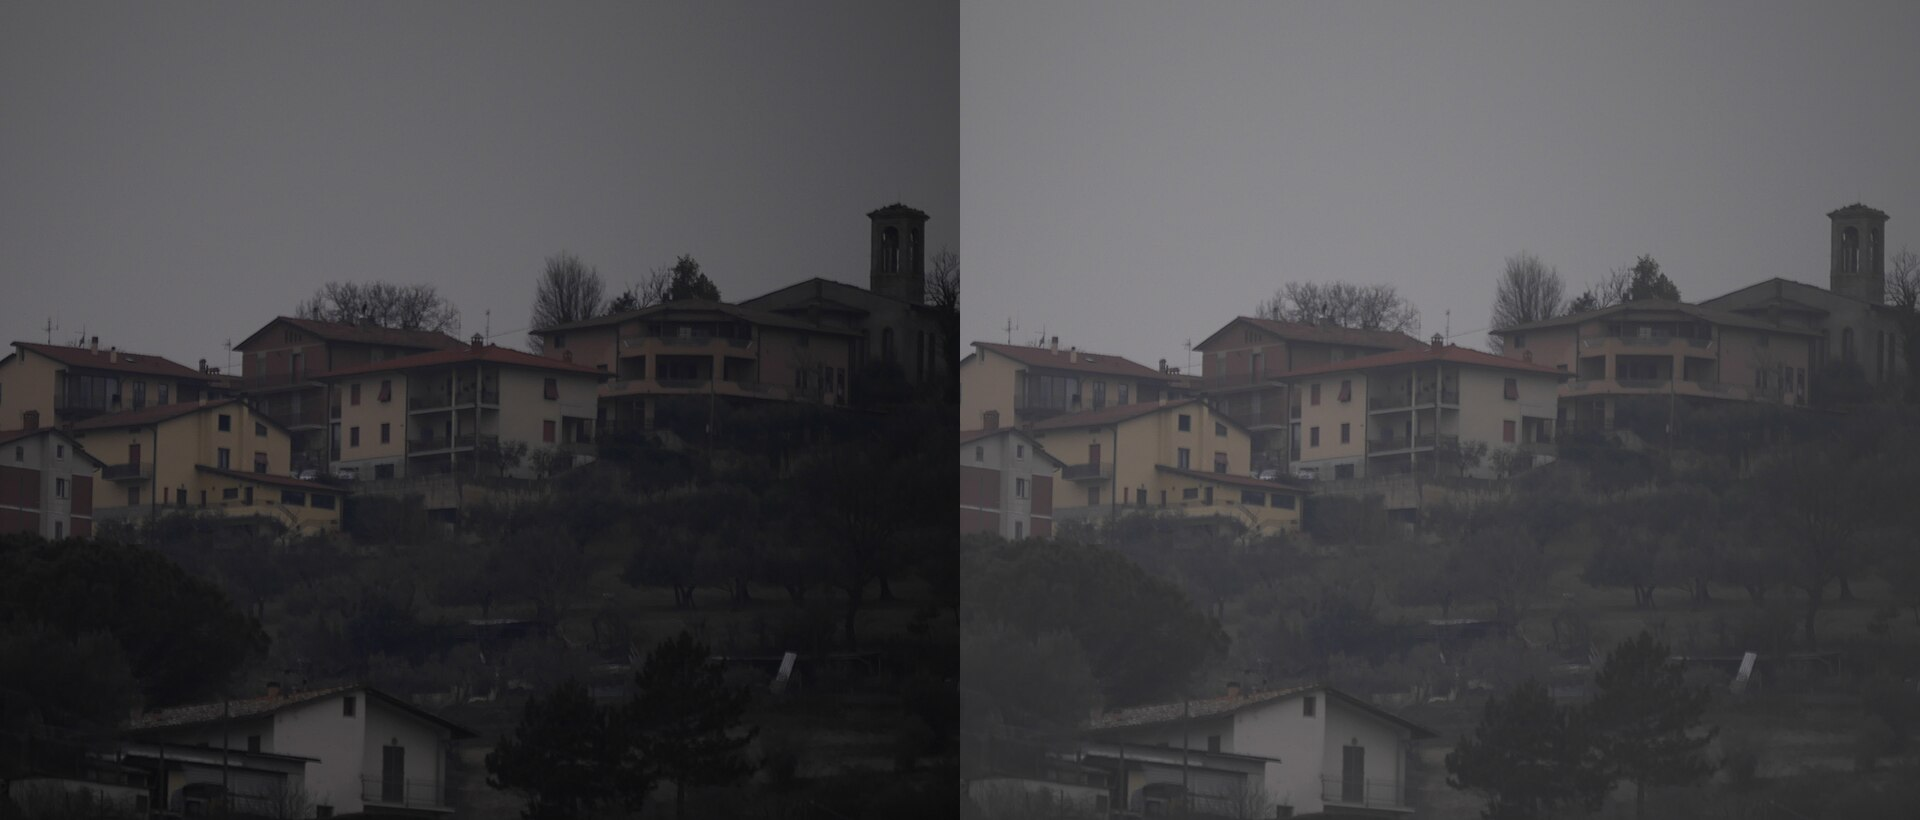

In [32]:
print(' Mengubah tingkat kecerahan citra ')
print('---------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
      for c in range(original.shape[2]):
          brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

1.  Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:
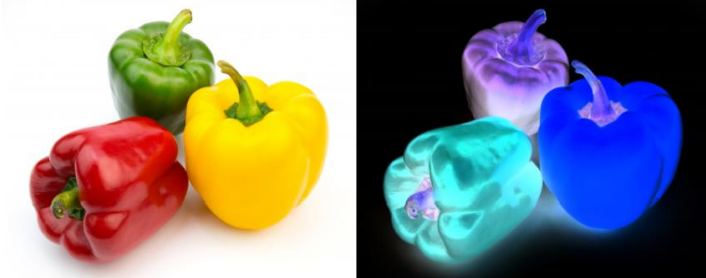

In [34]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

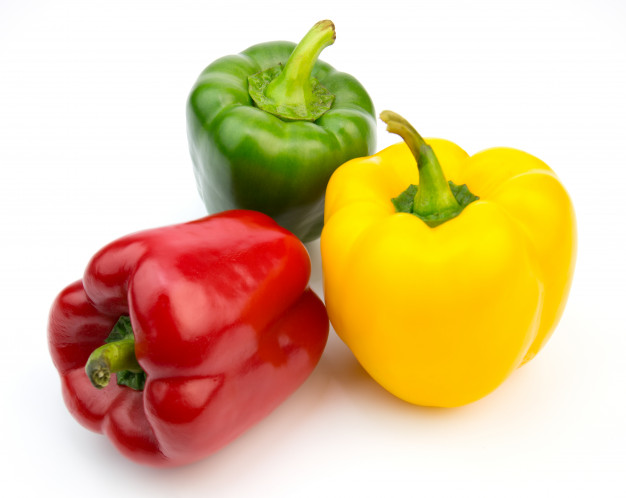

In [35]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')

cv2_imshow(original)

In [36]:
inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

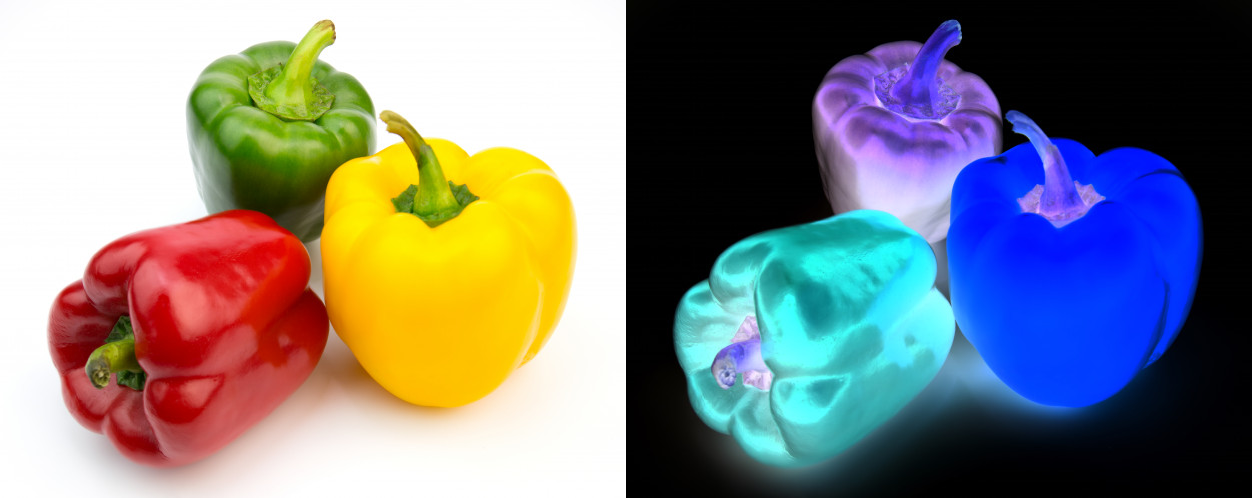

In [37]:
final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

Pada percobaan inverse citra, setiap nilai pixel RGB diubah menggunakan rumus 255 - nilai pixel asli. Proses ini menyebabkan warna terang menjadi gelap dan sebaliknya, sehingga menghasilkan citra negatif.

2.  Implementasikan transformasi contrast pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut: 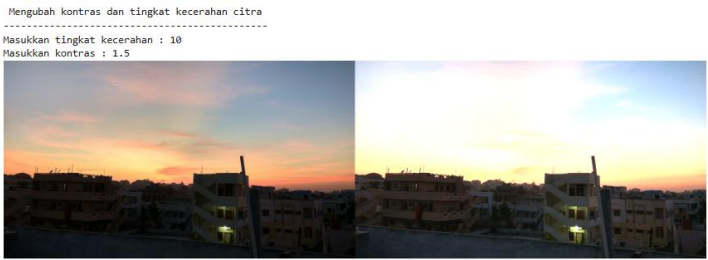

In [42]:
print('Mengubah tingkat contrast citra')
print('--------------------------------')

contrast = float(input('Masukkan nilai contrast: '))

Mengubah tingkat contrast citra
--------------------------------
Masukkan nilai contrast: 1.5


In [44]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/sunset.jpg')

contrast_image = np.zeros(original.shape, original.dtype)

In [45]:
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(
                contrast * original[y, x, c],
                0,
                255
            )

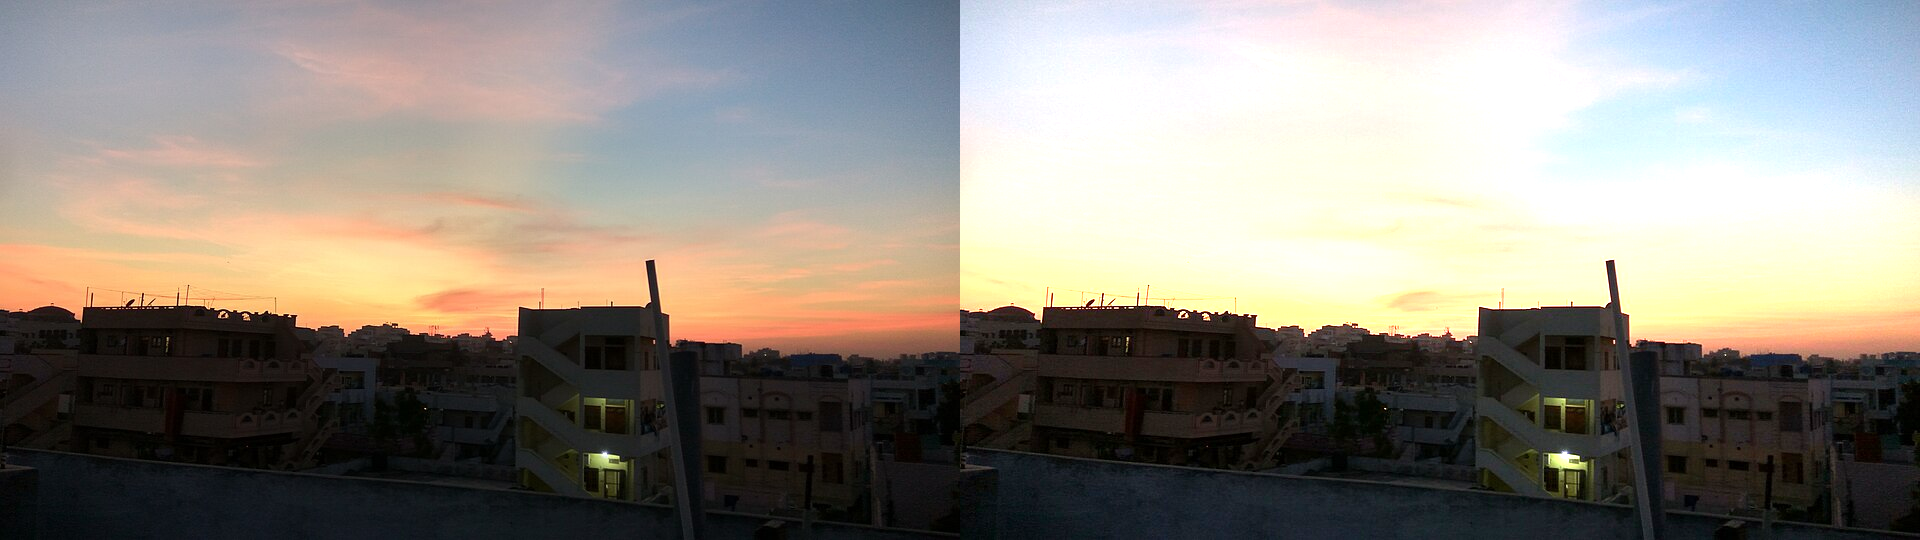

In [46]:
final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

Transformasi contrast dilakukan dengan mengalikan nilai pixel asli dengan konstanta contrast. Nilai contrast lebih dari 1 memperbesar perbedaan antara area terang dan gelap. Fungsi np.clip() digunakan agar nilai pixel tetap berada pada rentang 0–255.

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut: 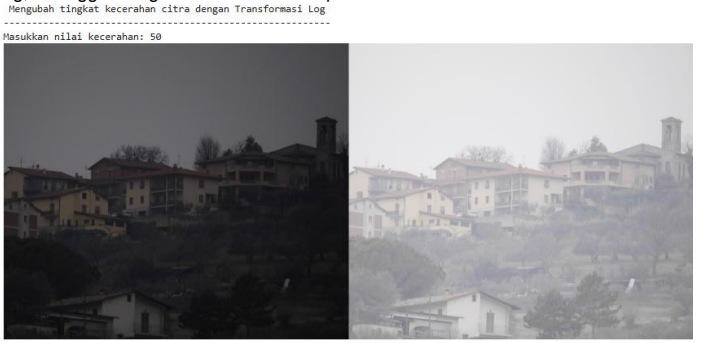

In [49]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

brightness = int(input('Masukkan nilai kecerahan: '))

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 50


In [50]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')

In [51]:
log_image = np.zeros(original.shape, original.dtype)
log_image = brightness * np.log1p(original.astype(np.float32))
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

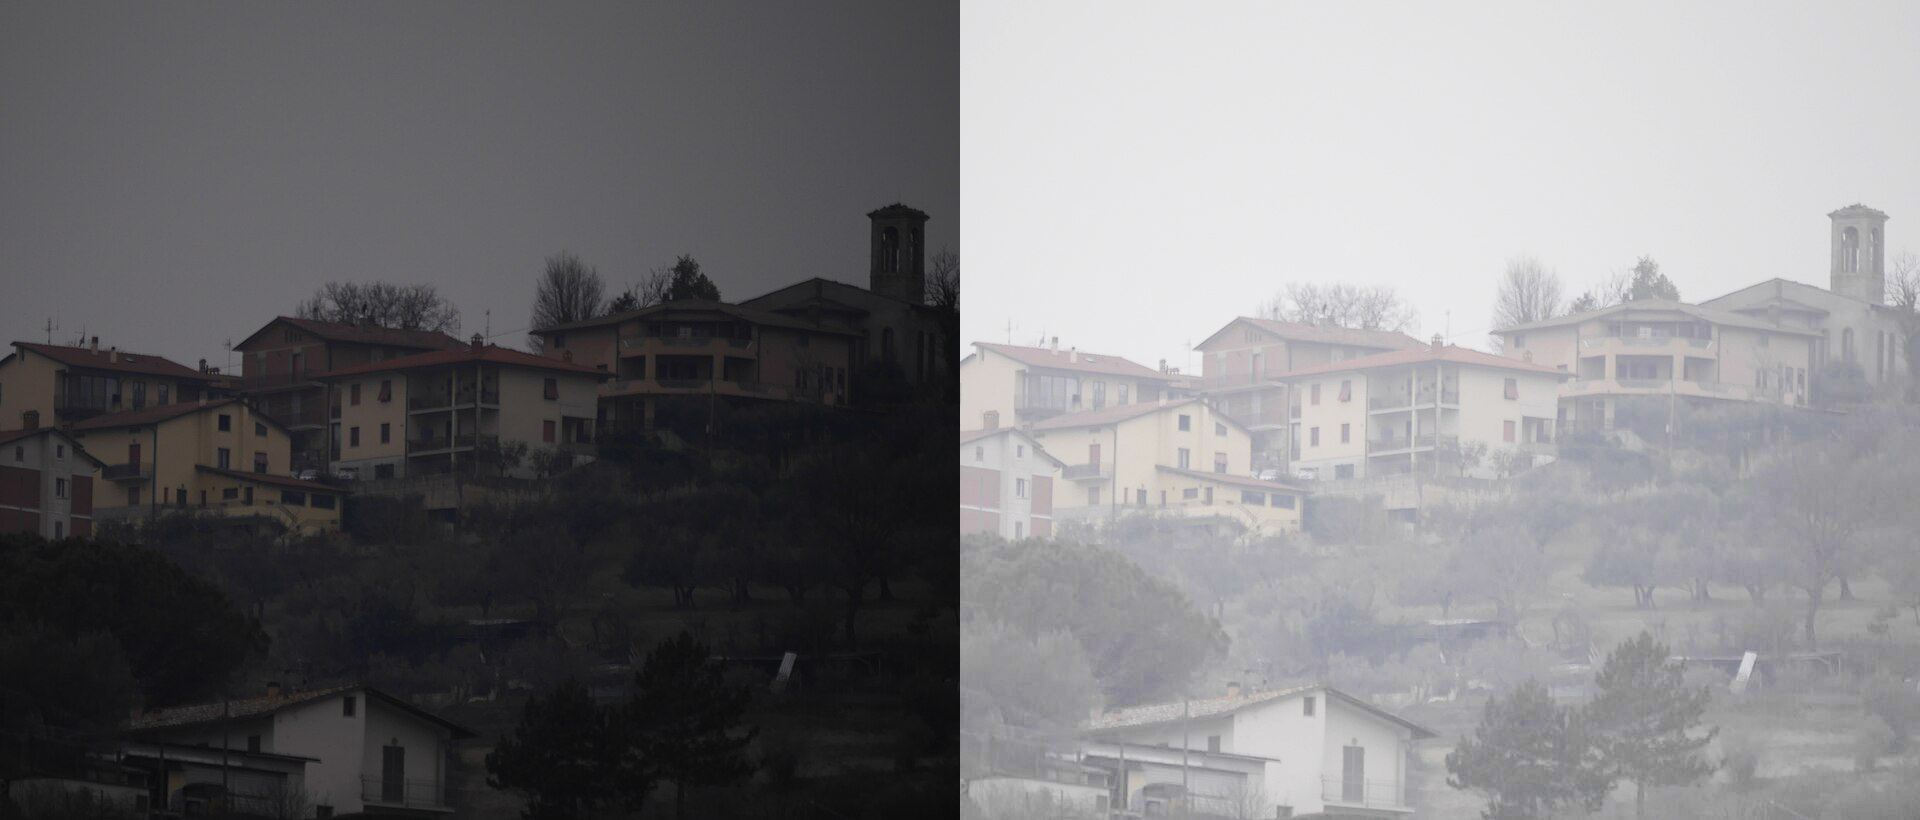

In [52]:
final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)

Logarithmic brightness meningkatkan detail pada pixel dengan intensitas rendah. Nilai pixel asli dikonversi menggunakan fungsi logaritma sehingga bagian gelap menjadi lebih terlihat.

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut: 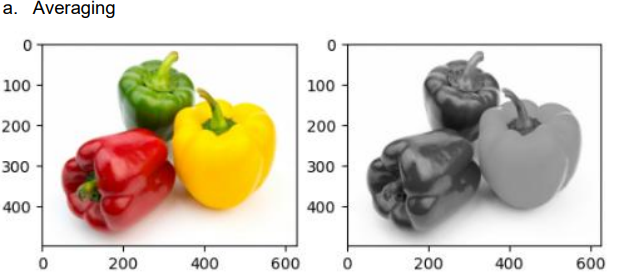

In [58]:
import matplotlib.pyplot as plt

In [54]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

In [55]:
R = original_rgb[:, :, 0]
G = original_rgb[:, :, 1]
B = original_rgb[:, :, 2]

In [56]:
gray_avg = ((R.astype(float) + G.astype(float) + B.astype(float)) / 3).astype(np.uint8)

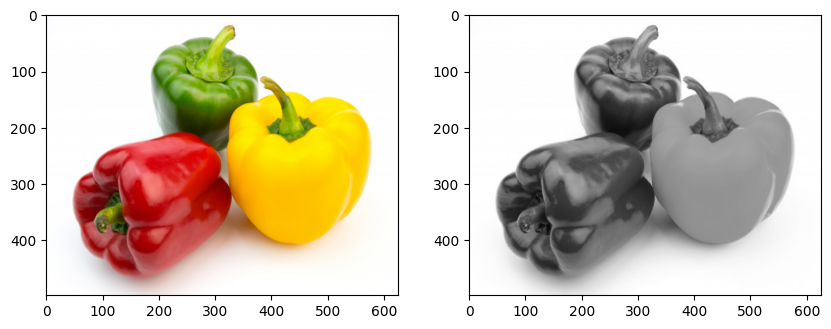

In [59]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)

plt.subplot(1, 2, 2)
plt.imshow(gray_avg, cmap='gray')

plt.show()

Metode Averaging mengubah citra RGB menjadi grayscale dengan menghitung rata-rata nilai channel Red, Green, dan Blue pada setiap pixel. Hasil citra asli dan grayscale ditampilkan berdampingan menggunakan Matplotlib agar koordinat pixel tetap terlihat.